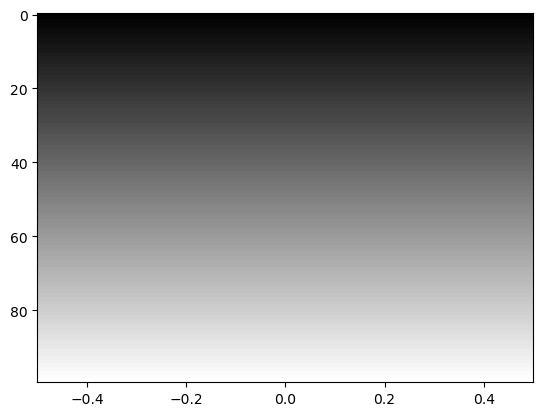

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

#definicion de colores
colores=[(0,'black'),(1,'white')]#para generar escala de grises

cmap = LinearSegmentedColormap.from_list('degradado',colores)#generamos color map a travez de nuesstro array
imagen_degra = cmap(np.linspace(0,1,100).reshape(-1,1))

plt.imshow(imagen_degra,aspect='auto')
plt.show()

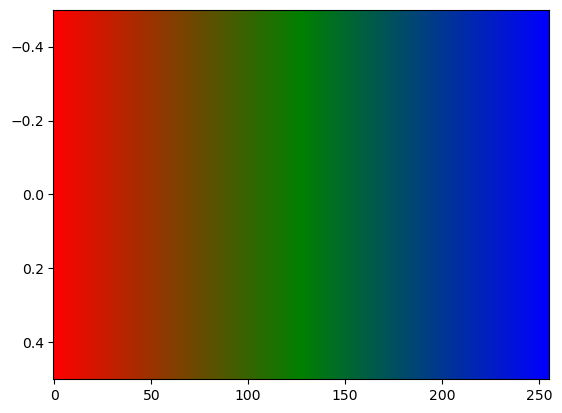

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

#definicion de colores
colores=[(0,'red'),(0.5,'green'),(1,'blue')]#para generar escala de grises
cmap = LinearSegmentedColormap.from_list('degradado',colores)#generamos color map a travez de nuesstro array
imagen_degra = cmap(np.linspace(0,1,256))

plt.imshow([imagen_degra],aspect='auto')
plt.show()

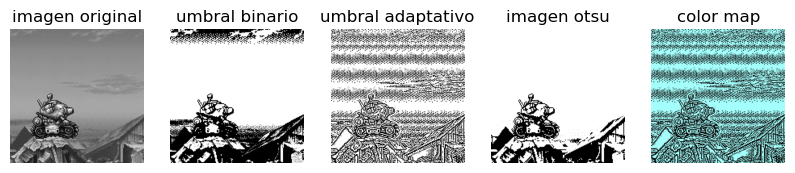

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('imgGIF3.jpg',0)
_,umbra_bi=cv2.threshold(imagen,127,255,cv2.THRESH_BINARY)
umb_adap=cv2.adaptiveThreshold(imagen,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY,11,2)
_,otsu = cv2.threshold(imagen,0,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU)
color = cv2.applyColorMap(umb_adap,cv2.COLORMAP_INFERNO)
plt.figure(figsize=(10,5))
plt.subplot(1,5,1)
plt.title('imagen original')
plt.imshow(imagen,cmap='gray')
plt.axis('off')

plt.subplot(1,5,2)
plt.title('umbral binario')
plt.imshow(umbra_bi,cmap='gray')
plt.axis('off')

plt.subplot(1,5,3)
plt.title('umbral adaptativo')
plt.imshow(umb_adap,cmap='gray')
plt.axis('off')

plt.subplot(1,5,4)
plt.title('imagen otsu')
plt.imshow(otsu,cmap='gray')
plt.axis('off')

plt.subplot(1,5,5)
plt.title('color map')
plt.imshow(color,cmap='gray')
plt.axis('off')

plt.show()

Mascaras

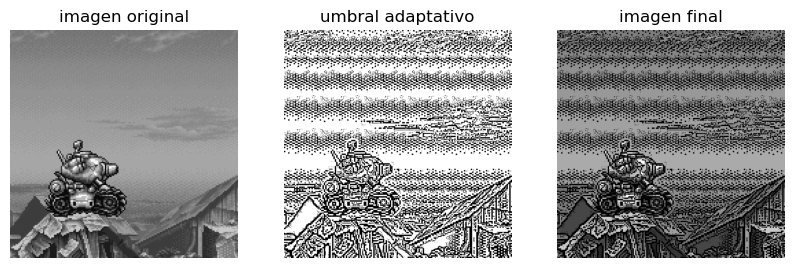

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('imgGIF3.jpg',0)
umb_adap=cv2.adaptiveThreshold(imagen,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY,11,2)
mask1= umb_adap == 255 #mascara binaria
img_juntar=cv2.bitwise_and(imagen,imagen,mask=umb_adap)

plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
plt.title('imagen original')
plt.imshow(imagen,cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title('umbral adaptativo')
plt.imshow(umb_adap,cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title('imagen final')
plt.imshow(img_juntar,cmap='gray')
plt.axis('off')

plt.show()

Solarizacion

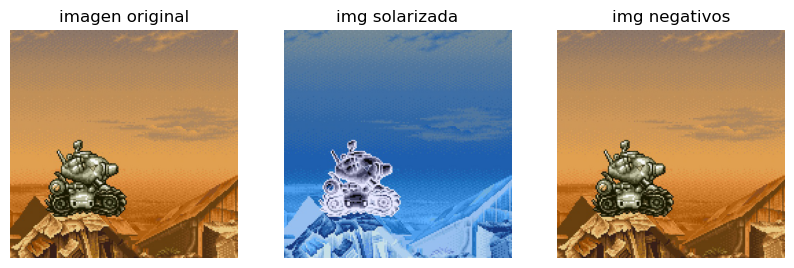

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def solarizar(imagen, umbral):
    img_solarizada = np.where(imagen<umbral,imagen,255-imagen)
    return img_solarizada

imagen = cv2.imread('imgGIF3.jpg')
img_sol = solarizar(imagen,0)
img_negativo=255-img_sol

plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
plt.title('imagen original')
plt.imshow(cv2.cvtColor(imagen,cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,3,2)
plt.title('img solarizada')
plt.imshow(cv2.cvtColor(img_sol,cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,3,3)
plt.title('img negativos')
plt.imshow(cv2.cvtColor(img_negativo,cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.show()